In [1]:
from mmspao.utils import *
from mmspao import mmspao
import scanpy as sc

set_random_seed(42)
device = 'cuda'


In [2]:
#Load data and perform necessary preprocessing
rna = sc.read('/home/data1/linjing0806/multiomics/SpatialGlue/data/Dataset1_Mouse_Spleen1/adata_RNA.h5ad')
protein = sc.read('/home/data1/linjing0806/multiomics/SpatialGlue/data/Dataset1_Mouse_Spleen1/adata_ADT.h5ad')
sc.pp.highly_variable_genes(rna, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(rna, target_sum=1e4)

rna =  rna[:, rna.var['highly_variable']]
adata = rna.copy()
rna = getX(rna,modality='rna')

/home/data1/linjing0806/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/data1/linjing0806/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/data1/linjing0806/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/data1/linjing0806/anaconda3/envs/pytorch_gpu/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
protein = getX(protein,modality='protein')

In [4]:
model = mmspao([rna,protein],sel_views='all',combination='all',sparse=True,device=device)
model.train()

perform PCA for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

sparse adj for each modality:   0%|          | 0/2 [00:00<?, ?it/s]

Training KAN for modality 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Training KAN for modality 2:   0%|          | 0/1000 [00:00<?, ?it/s]

In [5]:
model.cluster(adata, n_domains=8, end=2.0)

Leiden clustering:   0%|          | 0/190 [00:00<?, ?it/s]

Found resolution: 1.73 for 8 domains


1.7299999999999993

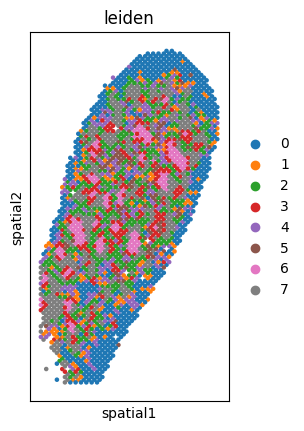

In [6]:
sc.pl.spatial(adata, color="leiden", spot_size=1.7, show=True)

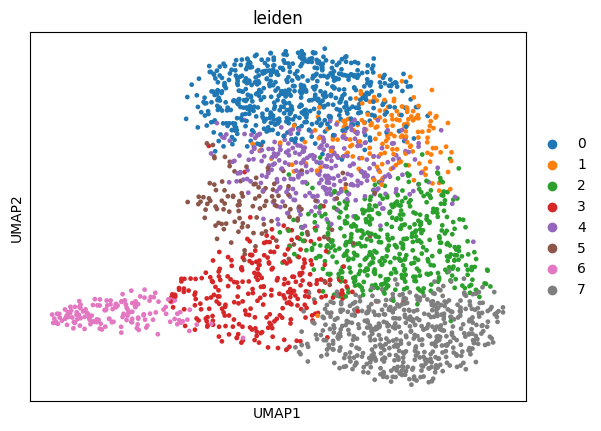

In [7]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden",)